# COVID-19 Analysis Dashboard

This notebook explores the global trend, country impact, and short-term forecasting of COVID-19 cases.


In [38]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [39]:
df = pd.read_csv('Covid.csv')

In [40]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [41]:
df.shape

(49068, 10)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  str    
 1   Country/Region  49068 non-null  str    
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  str    
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 5.2 MB


In [43]:
df.isnull().sum() 

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [44]:
# drop the state col, change the dtype for date, rename the country/region col to country
df.drop('Province/State',axis=1,inplace=True)
df['Date']=pd.to_datetime(df['Date'])
df.rename(columns={'Country/Region' : 'Country'}, inplace=True)
df = df.sort_values('Date').reset_index(drop=True)

In [45]:
# Q- How did the total number of confirmed COVID-19 cases change over time globally?
conf_cases = df.groupby('Date')['Confirmed'].sum().reset_index()
conf_cases.head()


,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


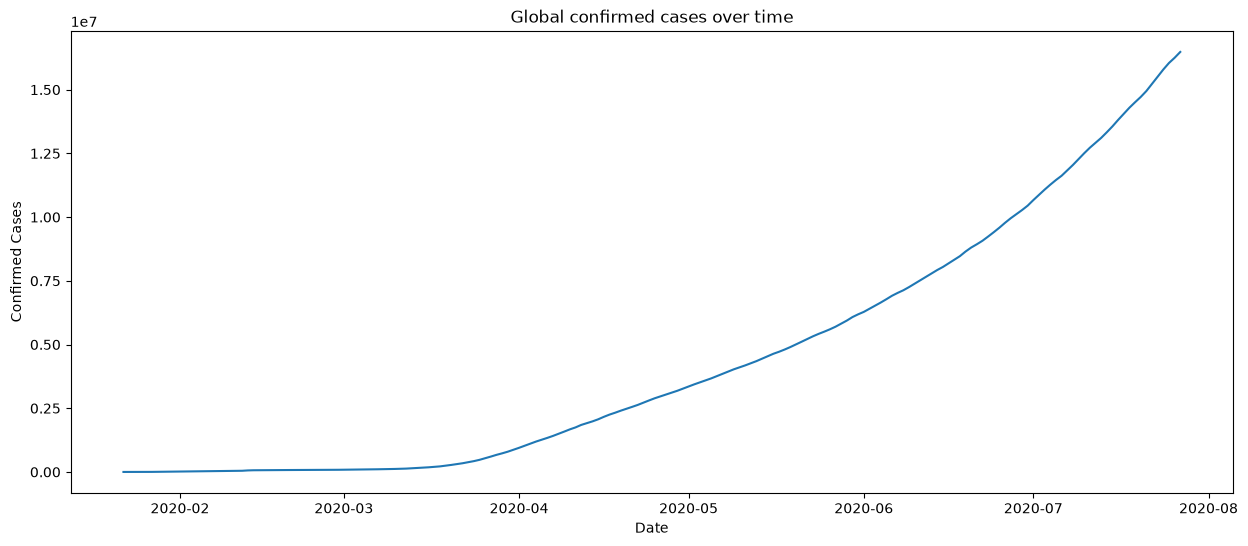

In [46]:
# Global confirmed cases trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=conf_cases, x='Date', y='Confirmed')
plt.title('Global confirmed cases over time')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.show()

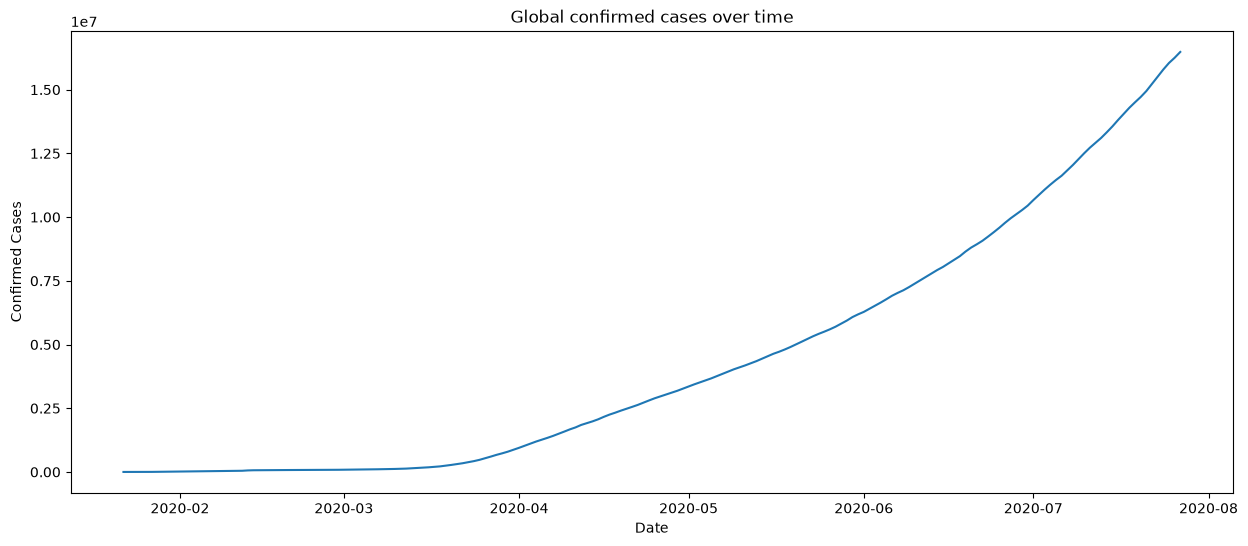

In [47]:
# Optional duplicate plot cell kept for reference
plt.figure(figsize=(15, 6))
sns.lineplot(data=conf_cases, x='Date', y='Confirmed')
plt.title('Global confirmed cases over time')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.show()

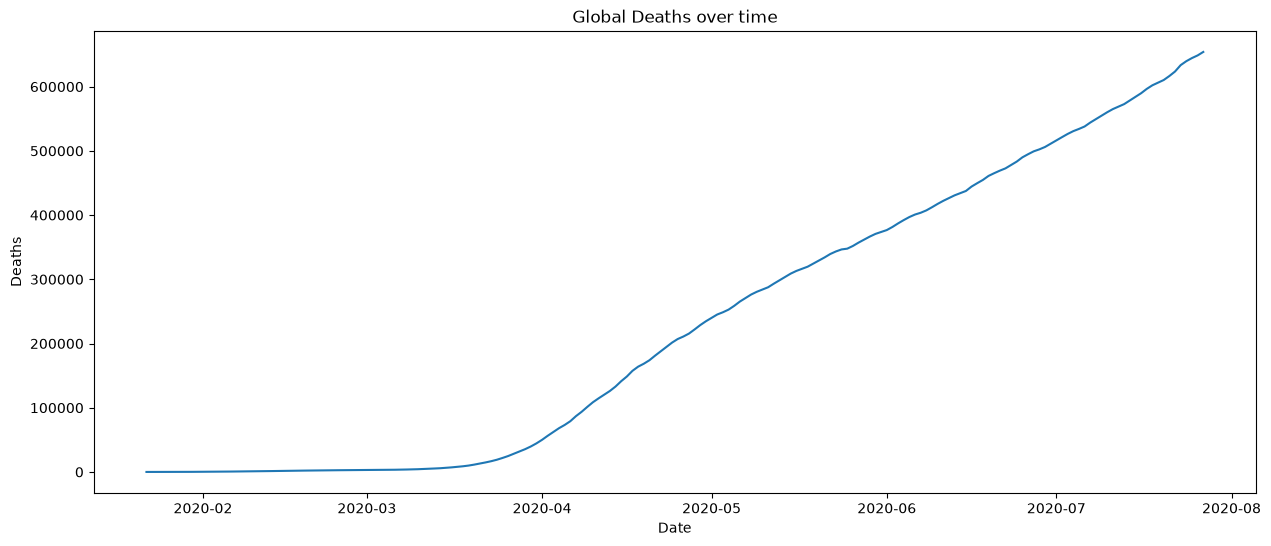

In [48]:
# Num of deaths as well as the num of active cases
death_cases=df.groupby('Date')['Deaths'].sum().reset_index()
death_cases.head()
plt.figure(figsize=(15,6))
sns.lineplot(data=death_cases,x='Date',y='Deaths')
plt.title('Global Deaths over time')
plt.xlabel('Date')
plt.ylabel('Deaths')
plt.show()


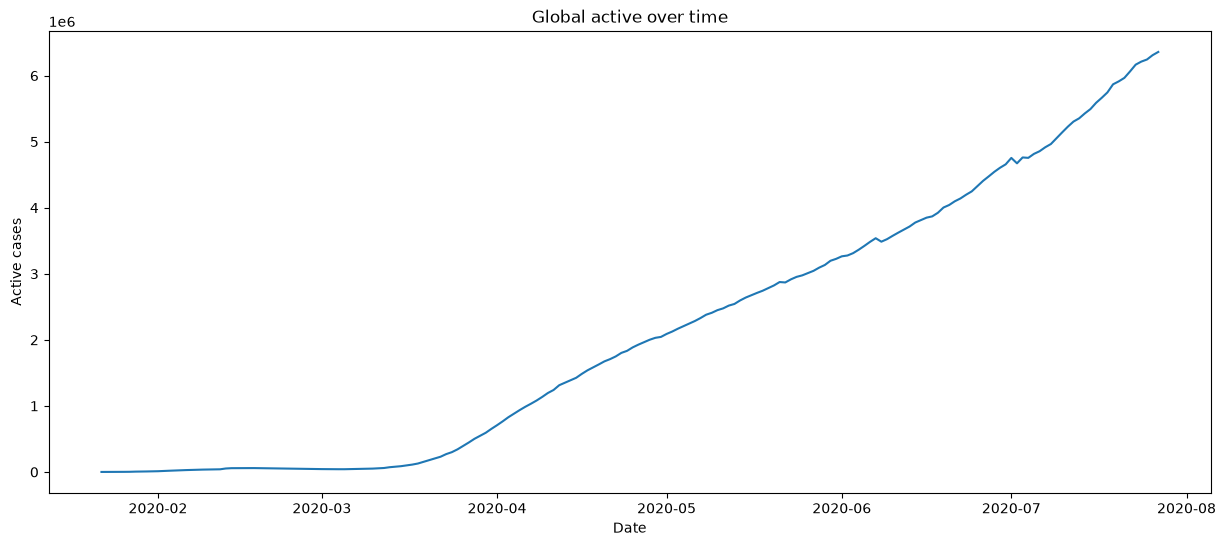

In [49]:
# Num of deaths as well as the num of active cases
act_cases=df.groupby('Date')['Active'].sum().reset_index()
act_cases.head()
plt.figure(figsize=(15,6))
sns.lineplot(data=act_cases,x='Date',y='Active')
plt.title('Global active over time')
plt.xlabel('Date')
plt.ylabel('Active cases')
plt.show()


In [50]:
# Which 3 countries were most affected by Covid-19

data_ct=df.groupby('Country')[['Confirmed','Active','Deaths','Recovered']].sum().reset_index()
data_ct.head()

top3_conf=data_ct.sort_values(by='Confirmed',ascending=False).head(3)
top3_deaths=data_ct.sort_values(by='Deaths',ascending=False).head(3)
top3_act=data_ct.sort_values(by='Active',ascending=False).head(3)
top3_rec=data_ct.sort_values(by='Recovered',ascending=False).head(3)

print(top3_deaths)



            Country  Confirmed     Active    Deaths  Recovered
173              US  224345948  156981121  11011411   56353416
177  United Kingdom   26748587   22624595   3997775     126217
23           Brazil   89524967   31094060   3938034   54492873


In [51]:
print(top3_act)


            Country  Confirmed     Active    Deaths  Recovered
173              US  224345948  156981121  11011411   56353416
23           Brazil   89524967   31094060   3938034   54492873
177  United Kingdom   26748587   22624595   3997775     126217


In [52]:
print(top3_conf)

    Country  Confirmed     Active    Deaths  Recovered
173      US  224345948  156981121  11011411   56353416
23   Brazil   89524967   31094060   3938034   54492873
138  Russia   45408411   19668578    619385   25120448


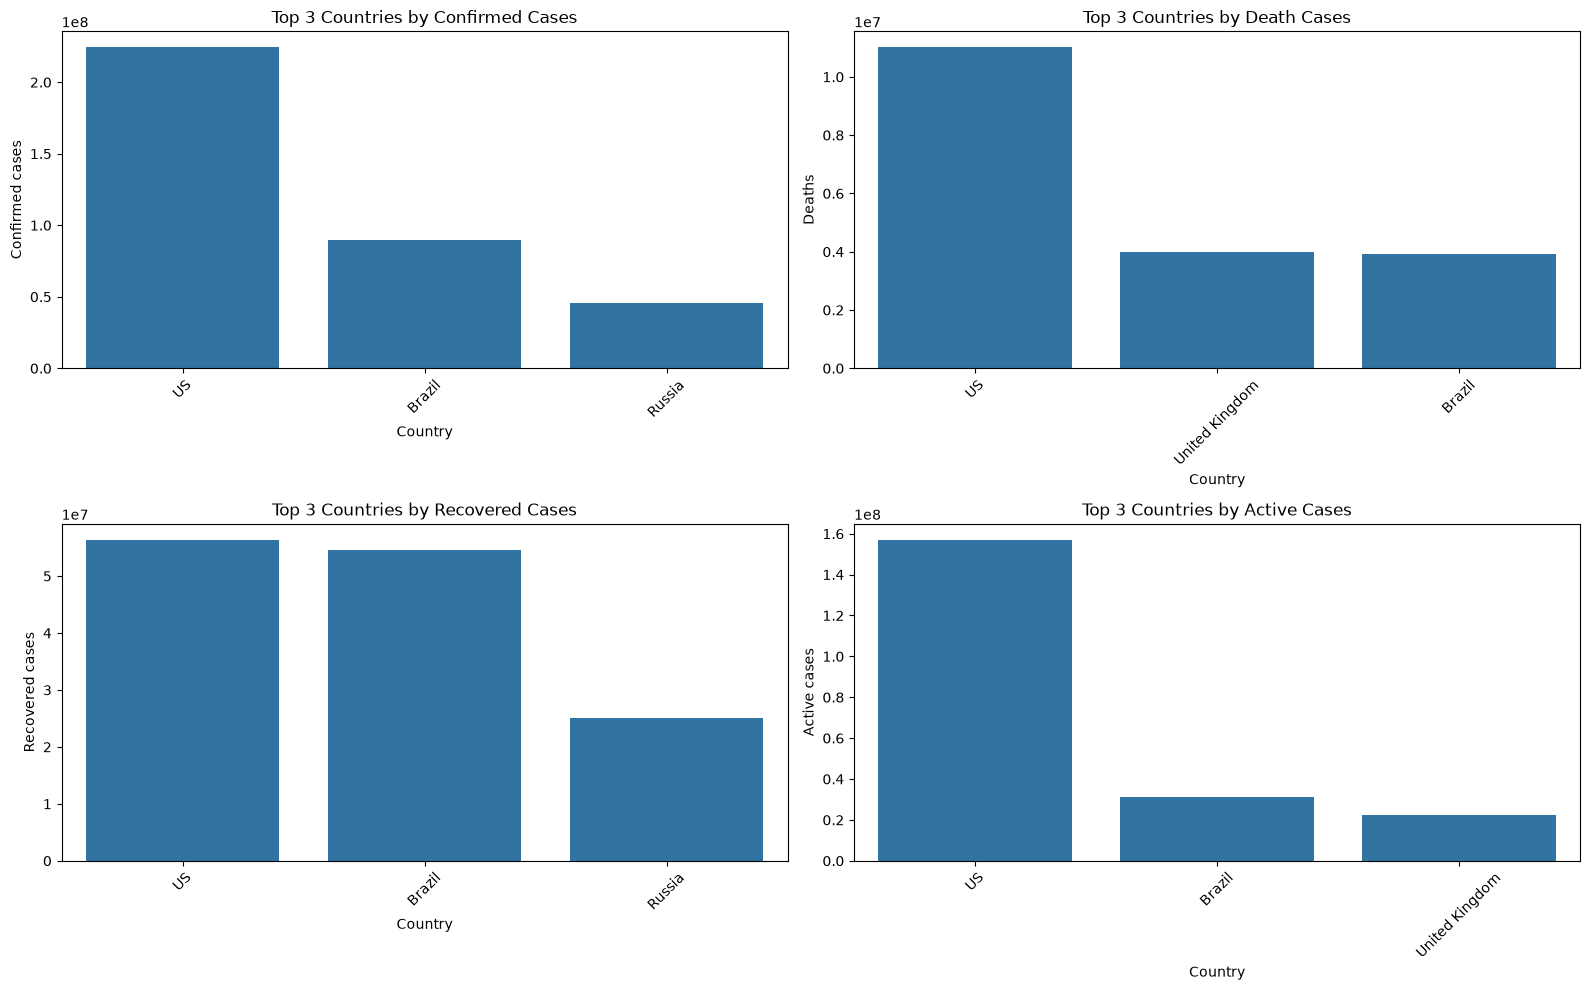

In [53]:
# How do the top 3 countries compare in terms of confirmed,death, active and recovered cases
plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
sns.barplot(data=top3_conf,x='Country',y='Confirmed')
plt.title('Top 3 Countries by Confirmed Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed cases')
plt.xticks(rotation=45)

plt.subplot(2,2,2)
sns.barplot(data=top3_deaths,x='Country',y='Deaths')
plt.title('Top 3 Countries by Death Cases')
plt.xlabel('Country')
plt.ylabel('Deaths')
plt.xticks(rotation=45)


plt.subplot(2,2,3)
sns.barplot(data=top3_rec,x='Country',y='Recovered')
plt.title('Top 3 Countries by Recovered Cases')
plt.xlabel('Country')
plt.ylabel('Recovered cases')
plt.xticks(rotation=45)

plt.subplot(2,2,4)
sns.barplot(data=top3_act,x='Country',y='Active')
plt.title('Top 3 Countries by Active Cases')
plt.xlabel('Country')
plt.ylabel('Active cases')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [54]:
# Forecasting setup
confirmed_cases = df.groupby('Date')['Confirmed'].sum().reset_index()
prophet_data = confirmed_cases.rename(columns={'Date': 'ds', 'Confirmed': 'y'})
prophet_data = prophet_data.sort_values('ds').reset_index(drop=True)

16:12:42 - cmdstanpy - INFO - Chain [1] start processing
16:12:42 - cmdstanpy - INFO - Chain [1] done processing


MAE 1510442.2401881344
RMSE: 1811725.9660910536
          Date    Actual     Predicted
150 2020-06-20   8805336  8.618788e+06
151 2020-06-21   8933875  8.735327e+06
152 2020-06-22   9071733  8.848277e+06
153 2020-06-23   9237071  8.967111e+06
154 2020-06-24   9408254  9.088591e+06
155 2020-06-25   9586141  9.212845e+06
156 2020-06-26   9777487  9.337835e+06
157 2020-06-27   9955597  9.452564e+06
158 2020-06-28  10117227  9.569103e+06
159 2020-06-29  10275799  9.682053e+06
160 2020-06-30  10449697  9.800888e+06
161 2020-07-01  10667386  9.922367e+06
162 2020-07-02  10875091  1.004662e+07
163 2020-07-03  11078585  1.017161e+07
164 2020-07-04  11272152  1.028634e+07
165 2020-07-05  11454847  1.040288e+07
166 2020-07-06  11622190  1.051583e+07
167 2020-07-07  11833034  1.063466e+07
168 2020-07-08  12044836  1.075614e+07
169 2020-07-09  12273063  1.088040e+07
170 2020-07-10  12505640  1.100539e+07
171 2020-07-11  12721968  1.112012e+07
172 2020-07-12  12914636  1.123666e+07
173 2020-07-13  

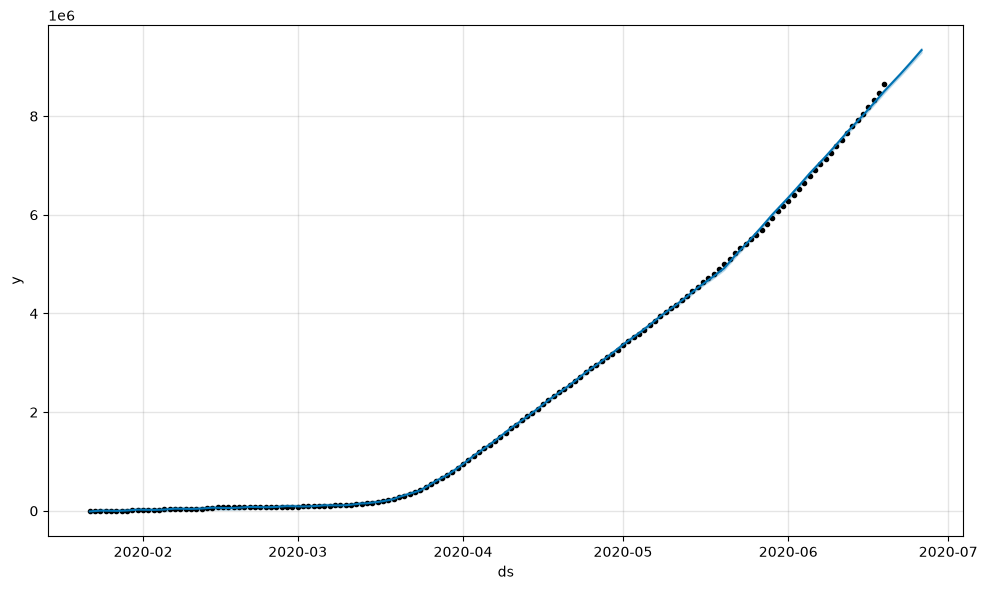

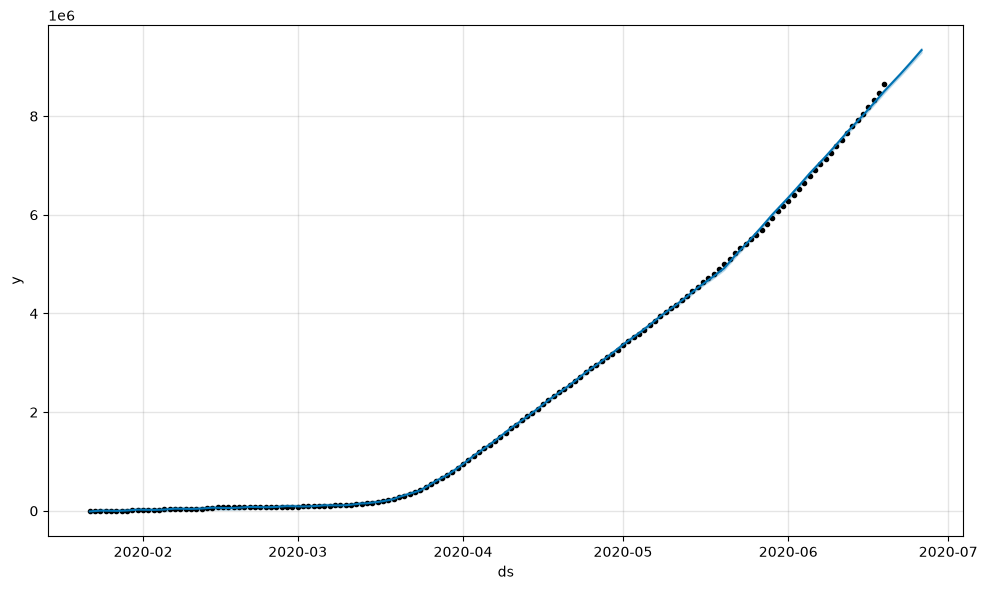

In [55]:
confirmed_cases=df.groupby('Date')['Confirmed'].sum().reset_index()
prophet_data=confirmed_cases.rename(
    columns={
        'Date' : 'ds',
        'Confirmed' : 'y'
    }
)
prophet_data=prophet_data.sort_values('ds').reset_index(drop=True)

train,test=train_test_split(prophet_data,test_size=0.2,shuffle=False)
model=Prophet()
model.fit(train)
forecast=model.predict(test[['ds']])
actual=test['y'].values
predicted=forecast['yhat'].values

mae=mean_absolute_error(actual,predicted)
rmse=np.sqrt(mean_squared_error(actual,predicted))

print("MAE",mae)
print('RMSE:',rmse)

res=pd.DataFrame({
    'Date' : test['ds'],
    'Actual' : actual,
    'Predicted' : predicted
})

print(res)

future = model.make_future_dataframe(periods=7)
final_forecast=model.predict(future)
print(final_forecast[
    ['ds','yhat_lower','yhat_upper','yhat']
].tail(7))

model.plot(final_forecast)
